In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.impute import SimpleImputer
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import patsy
import geopandas as gpd
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from matplotlib.ticker import FuncFormatter
import statsmodels.api as sm
import sys

In [2]:
RUN_BOTH_OUTPUT_MODES = True
base = "../outputs/tables/"
base_standardized = "../outputs/standardized_tables/"

y = "energy_burden_pct"  # change this to "y_pv", "y_storage", "y_chargers", "y_wind_mw", "energy_burden_pct", or "log_energy_gap_per_capita"


def prep_outcomes_per_capita(df, pop_col="total_population", min_pop=1000):
    """Create per-capita + log1p outcomes; filter tiny-pop ZIPs."""
    df = df.copy()
    df[pop_col] = pd.to_numeric(df[pop_col], errors="coerce")
    df = df[df[pop_col].notna() & (df[pop_col] >= min_pop)].copy()

    pop = df[pop_col].replace(0, np.nan)
    df["level2_chargers_per_1k"] = df["level2_chargers"] * 1000 / pop
    df["y_level2_chargers"] = np.log1p(df["level2_chargers_per_1k"])

    df["level1_chargers_per_1k"] = df["level1_chargers"] * 1000 / pop
    df["y_level1_chargers"] = np.log1p(df["level1_chargers_per_1k"])

    df["dc_fast_chargers_per_1k"] = df["dc_fast_chargers"] * 1000 / pop
    df["y_dc_fast_chargers"] = np.log1p(df["dc_fast_chargers_per_1k"])

    df["chargers_per_1k"] = df["total_chargers"] * 1000 / pop
    df["y_chargers"] = np.log1p(df["chargers_per_1k"])

    df["pv_kw_per_1k"] = df["PV_system_size_DC"] * 1000 / pop
    df["y_pv"] = np.log1p(df["pv_kw_per_1k"])

    df["storage_mw_per_100k"] = df["storage_capacity_mw"] * 100000 / pop
    df["y_storage"] = np.log1p(df["storage_mw_per_100k"])

    df["wind_mw_per_100k"] = df["wind_capacity_mw"] * 100000 / pop
    df["y_wind_mw"] = np.log1p(df["wind_mw_per_100k"])

    df["plant_mw_per_100k"] = df["plant_capacity_mw"] * 100000 / pop
    df["wind_mw_per_100k_ctrl"] = df["wind_capacity_mw"] * 100000 / pop
    df["turbines_per_100k"] = df["wind_turbine_count"] * 100000 / pop

    df["log_median_household_income"] = np.log(df["median_household_income"].where(df["median_household_income"] > 0))
    df["log_median_housing_value"] = np.log(df["median_housing_value"].where(df["median_housing_value"] > 0))
    df["combined_nonwhite_share"] = df[["pct_black", "pct_hispanic", "pct_asian"]].sum(axis=1, min_count=1)

    df["energy_burden_pct"] = pd.to_numeric(df["energy_burden_pct"], errors="coerce")
    df["energy_gap_per_capita"] = df["energy_affordability_gap"] / pop
    df["log_energy_gap_per_capita"] = np.log1p(df["energy_gap_per_capita"])

    return df


def center_cols(df, cols):
    """Mean-center columns for interaction models."""
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c + "_c"] = df[c] - df[c].mean()
    return df


def run_ols(formula, df, cluster_col=None):
    """Run OLS with HC1 SEs by default; optional clustered SEs."""
    m = smf.ols(formula=formula, data=df)

    if cluster_col is None:
        return m.fit(cov_type="HC1")
    res = m.fit()
    used_idx = res.model.data.row_labels
    groups = df.loc[used_idx, cluster_col].copy()
    groups = groups.fillna("MISSING").astype(str)
    return m.fit(cov_type="cluster", cov_kwds={"groups": groups})


def vif_from_formula(formula, df, exclude_prefixes=("C(",), drop_intercept=True):
    y_mat, X = patsy.dmatrices(formula, df, return_type="dataframe")

    if drop_intercept and "Intercept" in X.columns:
        X = X.drop(columns=["Intercept"])

    if exclude_prefixes:
        keep = []
        for col in X.columns:
            if not any(col.startswith(pref) for pref in exclude_prefixes):
                keep.append(col)
        X = X[keep]

    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    vif = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values("VIF", ascending=False)

    return vif


In [3]:
#### THIS IS JUST FOR CALCULATING DIFFERENT FEATURES
#### ONLY MODIFY TO ADD FEATURES
df = pd.read_csv("../data/processed/combined_der_dataset_w_controls_predictors.csv")
df.drop(columns=['Unnamed: 0'], inplace=True, errors="ignore")
df.rename(columns={"ghi_mean_kwh_m2_day_2024":"ghi_mean_kwh_m2_day_2023",
"wind_ws10m_mean_2024": "wind_ws10m_mean_2023",
    "wind_ws50m_mean_2024": "wind_ws50m_mean_2023"}, inplace=True)
# numeric coercion for key vars (safe)
for c in [
    "median_household_income", "poverty_rate", "pct_bachelors_plus",
    "pct_black", "pct_hispanic", "pct_asian", "median_housing_value",
    "cdd65_2023", "hdd65_2023", "t2m_mean_c_2023",
    "ghi_mean_kwh_m2_day_2023", "wind_ws10m_mean_2023", "wind_ws50m_mean_2023",
    "total_population", "lat", "lon", "log_kwh",
    "plant_capacity_mw", "storage_capacity_mw", "wind_capacity_mw", "wind_turbine_count",
    "PV_system_size_DC", "total_chargers", "level1_chargers", "level2_chargers", "dc_fast_chargers",
]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["utility_type"] = df["utility_type"].fillna("POU")
df = prep_outcomes_per_capita(df, min_pop=1000)

core_needed = ["median_household_income", "pct_black", "pct_hispanic", "pct_asian"]
df = df.dropna(subset=[c for c in core_needed if c in df.columns]).copy()

<Axes: >

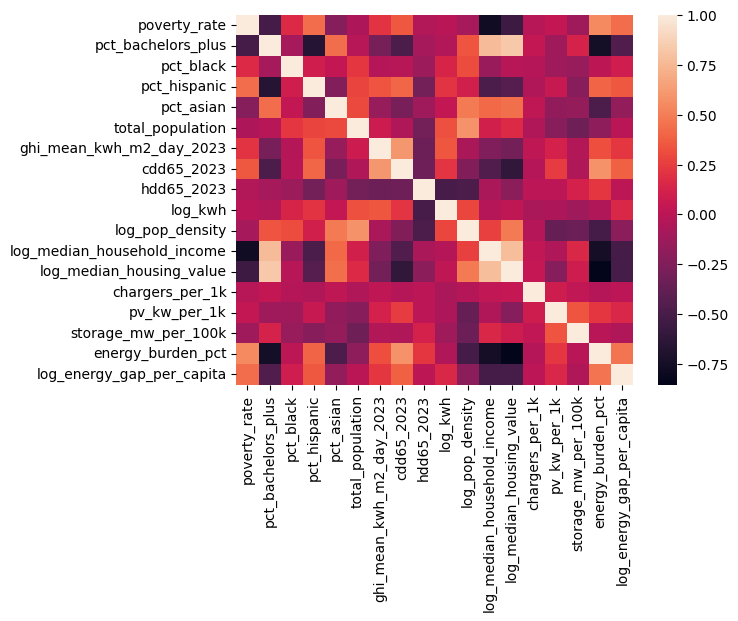

In [4]:
corr = df[[
       'poverty_rate',
       'pct_bachelors_plus', 'pct_black', 'pct_hispanic', 'pct_asian',
       'total_population', 'ghi_mean_kwh_m2_day_2023',
       'cdd65_2023', 'hdd65_2023',
       'log_kwh',
       'log_pop_density',
       'log_median_household_income', 'log_median_housing_value',
       'chargers_per_1k', #'y_chargers',
       'pv_kw_per_1k', #'y_pv',
       'storage_mw_per_100k', #'y_storage', 'y_wind_mw',
       "energy_burden_pct",
       "log_energy_gap_per_capita"
       ]].corr()

sns.heatmap(corr)

In [5]:

sys.path.append(str(Path("../scripts").resolve()))
from paper_figure_utils import GRID, MUTED, PAPER_BG, TERM_COLORS, apply_paper_style

OUTPUT_TABLE_DIRS = {
    False: Path("../outputs/tables"),
    True: Path("../outputs/standardized_tables"),
}
GENERATED_FIG_DIR = Path("../outputs/figures/generated")
RUN_MAPS = False
SUPPORTED_NOTEBOOK_OUTCOMES = {"y_pv", "y_storage", "y_chargers", "y_wind_mw", "energy_burden_pct", "log_energy_gap_per_capita"}
LOWESS_SEED = 42
LOWESS_FRAC = 0.35
LOWESS_BOOTSTRAPS = 300
LOWESS_GRID_SIZE = 200
LOWESS_CI = 95

income = "log_median_household_income"
race = ["pct_black", "pct_hispanic", "pct_asian"]
race_summary = "combined_nonwhite_share"
controls_common = ["poverty_rate"]
controls_3A = ["cdd65_2023", "hdd65_2023"]
controls_3B = ["t2m_mean_c_2023"]
controls_3C = ["ghi_mean_kwh_m2_day_2023"]
controls_3D = ["wind_ws50m_mean_2023"]
ses_bach = ["pct_bachelors_plus"]
ses_house = ["log_median_housing_value"]
utility_fe = "C(utility)"
cluster_utility = "utility"
df["county_geoid"] = df["county_geoid"].astype(str)
county_fe = "C(county_geoid)"
latlon = ["lat", "lon"]
demand_proxy = "log_kwh"
energy_burden_features = ["energy_burden_pct", "log_energy_gap_per_capita"]

term_labels = {
    "cdd65_2023": "Cooling degree days",
    "hdd65_2023": "Heating degree days",
    "ghi_mean_kwh_m2_day_2023": "Solar irradiance (GHI)",
    "wind_ws10m_mean_2023": "Wind speed (10m)",
    "wind_ws50m_mean_2023": "Wind speed (50m)",
    "poverty_rate": "Poverty rate",
    "pct_bachelors_plus": "% Bachelor's+",
    "pct_black": "% Black",
    "pct_hispanic": "% Hispanic",
    "pct_asian": "% Asian",
    "combined_nonwhite_share": "Combined non-white share",
    "log_median_household_income": "Log median household income",
    "log_median_housing_value": "Log median housing value",
    "log_pop_density": "Log population density",
    "log_kwh": "Log annual electricity demand",
    "energy_burden_pct": "Energy burden",
    "energy_affordability_index": "Energy affordability index",
    "log_energy_gap_per_capita": "Log energy affordability gap per capita",
    "y_pv": "Solar PV adoption",
    "y_chargers": "EV charger availability",
    "y_storage": "Storage deployment",
    "y_wind_mw": "Wind capacity",
}

analysis_df_raw = df.copy()


In [6]:
def build_formula(outcome, climate_controls, extra_terms=None, fe_terms=None,
                  keepincome=True, demand_proxy_term=None, controls_common_terms=None):
    rhs = []
    if keepincome:
        rhs.append(income)
    rhs += race
    rhs += list(controls_common_terms or controls_common)
    if demand_proxy_term is not None:
        rhs.append(demand_proxy_term)
    rhs += list(climate_controls or [])
    if extra_terms:
        rhs += list(extra_terms)
    if fe_terms:
        rhs += list(fe_terms)
    seen = set()
    rhs = [x for x in rhs if not (x in seen or seen.add(x))]
    return f"{outcome} ~ " + " + ".join(rhs)


def controls_for_outcome(outcome):
    if outcome == "y_pv":
        return controls_3C
    if outcome == "y_storage":
        return controls_3A
    if outcome == "y_chargers":
        return controls_3A
    if outcome == "y_wind_mw":
        return controls_3D
    if outcome in energy_burden_features:
        return controls_3A + controls_3C
    return []


def standardize_model_frame(source_df, outcome):
    df_model = source_df.copy()
    candidate_standardized_predictors = [
        "log_median_household_income",
        "log_median_housing_value",
        "log_pop_density",
        "poverty_rate",
        "pct_bachelors_plus",
        "pct_black",
        "pct_hispanic",
        "pct_asian",
        "combined_nonwhite_share",
        "cdd65_2023",
        "hdd65_2023",
        "t2m_mean_c_2023",
        "ghi_mean_kwh_m2_day_2023",
        "wind_ws10m_mean_2023",
        "wind_ws50m_mean_2023",
        "lat",
        "lon",
        "log_kwh",
        "plant_capacity_mw",
        "storage_capacity_mw",
        "wind_capacity_mw",
        "wind_turbine_count",
        "PV_system_size_DC",
        "plant_mw_per_100k",
        "storage_mw_per_100k",
        "wind_mw_per_100k_ctrl",
        "turbines_per_100k",
        "energy_burden_pct",
        "energy_affordability_index",
        "log_energy_gap_per_capita",
        "y_pv",
        "y_storage",
        "y_chargers",
        "y_wind_mw",
        "y_level1_chargers",
        "y_level2_chargers",
        "y_dc_fast_chargers",
    ]
    cols_to_standardize = [
        c for c in candidate_standardized_predictors
        if c in df_model.columns and c != outcome and df_model[c].nunique(dropna=True) > 1
    ]
    if cols_to_standardize:
        df_model[cols_to_standardize] = StandardScaler().fit_transform(df_model[cols_to_standardize])
    return df_model


def export_result_table(res, title, table_dir):
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(res.summary().tables[0])
    print(res.summary().tables[1])
    table_dir.mkdir(parents=True, exist_ok=True)
    res.summary2().tables[1].to_csv(table_dir / f"{title}.csv")


def export_vif_table(formula, df_model, title, table_dir):
    vif = vif_from_formula(formula, df_model)
    print(vif.head(30))
    vif.to_csv(table_dir / f"{title} VIF.csv", index=False)
    return vif


def run_outcome_suite(outcome, source_df, standardized_flag):
    table_dir = OUTPUT_TABLE_DIRS[standardized_flag]
    mode_label = "standardized" if standardized_flag else "raw"
    controls_cur = controls_for_outcome(outcome)
    df_model = standardize_model_frame(source_df, outcome) if standardized_flag else source_df.copy()

    def store_result(label, res):
        export_result_table(res, f"{outcome} | {label}", table_dir)
        return res

    f1 = build_formula(outcome, climate_controls=controls_cur, controls_common_terms=["poverty_rate"])
    res1 = store_result("Model 1 baseline (climate controls)", run_ols(f1, df_model))
    export_vif_table(f1, df_model, f"{outcome} | Model 1 baseline (climate controls)", table_dir)

    f2a = build_formula(outcome, climate_controls=controls_cur, extra_terms=ses_bach, keepincome=True, controls_common_terms=["poverty_rate"])
    res2a = store_result("Model 2 (add bachelors)", run_ols(f2a, df_model))
    export_vif_table(f2a, df_model, f"{outcome} | Model 2 (add bachelors)", table_dir)

    f2b = build_formula(outcome, climate_controls=controls_cur, extra_terms=ses_house, keepincome=True, controls_common_terms=["poverty_rate"])
    res2b = store_result("Model 2 (add housing value)", run_ols(f2b, df_model))
    export_vif_table(f2b, df_model, f"{outcome} | Model 2 (add housing value)", table_dir)

    f3a = build_formula(outcome, climate_controls=controls_3A)
    res3a = store_result("Model 3A (HDD + CDD)", run_ols(f3a, df_model))
    export_vif_table(f3a, df_model, f"{outcome} | Model 3A (HDD + CDD)", table_dir)

    f3b = build_formula(outcome, climate_controls=controls_3B)
    res3b = store_result("Model 3B (temp only)", run_ols(f3b, df_model))
    export_vif_table(f3b, df_model, f"{outcome} | Model 3B (temp only)", table_dir)

    f3c = build_formula(outcome, climate_controls=controls_3C)
    res3c = store_result("Model 3C (GHI only)", run_ols(f3c, df_model))
    export_vif_table(f3c, df_model, f"{outcome} | Model 3C (GHI only)", table_dir)

    df_int = center_cols(df_model, [income] + race)
    f4 = (
        f"{outcome} ~ log_median_household_income_c + pct_black_c + pct_hispanic_c + pct_asian_c"
        + (" + " + " + ".join(["poverty_rate"] + list(controls_cur)) if controls_cur else " + poverty_rate")
        + " + log_median_household_income_c:pct_black_c"
        + " + log_median_household_income_c:pct_hispanic_c"
        + " + log_median_household_income_c:pct_asian_c"
    )
    res4 = store_result("Model 4 interactions (centered)", run_ols(f4, df_int))
    export_vif_table(f4, df_int, f"{outcome} | Model 4 interactions (centered)", table_dir)

    f4r = (
        f"{outcome} ~ log_median_household_income_c + pct_black_c + pct_hispanic_c + pct_asian_c"
        + (" + " + " + ".join(list(controls_common) + list(controls_cur)) if controls_cur else " + " + " + ".join(list(controls_common)))
        + " + log_median_household_income_c:pct_black_c"
        + " + log_median_household_income_c:pct_hispanic_c"
        + " + log_median_household_income_c:pct_asian_c"
    )
    res4r = store_result("Model 4R interactions (centered)", run_ols(f4r, df_int))
    export_vif_table(f4r, df_int, f"{outcome} | Model 4R interactions (centered)", table_dir)

    f5 = build_formula(outcome, climate_controls=controls_cur, fe_terms=[utility_fe])
    res5 = store_result("Model 5 utility FE", run_ols(f5, df_model))
    export_vif_table(f5, df_model, f"{outcome} | Model 5 utility FE", table_dir)
    res5c = store_result("Model 5C clustered SEs by county", run_ols(f5, df_model, cluster_col="county_geoid"))

    f6a = build_formula(outcome, climate_controls=[], extra_terms=latlon)
    res6a = store_result("Model 6A lat and lon", run_ols(f6a, df_model))
    export_vif_table(f6a, df_model, f"{outcome} | Model 6A lat and lon", table_dir)

    f6b = build_formula(outcome, climate_controls=[], extra_terms=[county_fe])
    res6b = store_result("Model 6B county fe", run_ols(f6b, df_model))
    export_vif_table(f6b, df_model, f"{outcome} | Model 6B county fe", table_dir)
    res6_cluster = store_result("No County FE + clustered SEs (county)", run_ols(f1, df_model, cluster_col="county_geoid"))

    exclude_for_y = {
        "y_chargers": ["total_chargers", "level1_chargers", "level2_chargers", "dc_fast_chargers", "chargers_per_1k"],
        "y_pv": ["PV_system_size_DC", "pv_kw_per_1k", "y_pv"],
        "y_storage": ["storage_capacity_mw", "storage_mw_per_100k"],
        "y_wind_mw": ["wind_capacity_mw", "wind_mw_per_100k"],
    }
    infra_candidates = ["plant_capacity_mw", "storage_capacity_mw", "wind_capacity_mw", "wind_turbine_count", "PV_system_size_DC"]
    infra = [c for c in infra_candidates if c in df_model.columns and c not in exclude_for_y.get(outcome, [])]
    f7 = build_formula(outcome, climate_controls=controls_cur, extra_terms=infra)
    res7 = store_result("Model 7 (infrastructure controls, outcome-safe)", run_ols(f7, df_model))
    export_vif_table(f7, df_model, f"{outcome} | Model 7 (infrastructure controls, outcome-safe)", table_dir)

    infra_pc = [c for c in ["plant_mw_per_100k", "storage_mw_per_100k", "wind_mw_per_100k_ctrl", "turbines_per_100k"] if c in df_model.columns]
    infra_pc = [c for c in infra_pc if c not in exclude_for_y.get(outcome, [])]
    f7pc = build_formula(outcome, climate_controls=controls_cur, extra_terms=infra_pc)
    res7pc = store_result("Model 7 (per-capita infrastructure controls)", run_ols(f7pc, df_model))
    export_vif_table(f7pc, df_model, f"{outcome} | Model 7 (per-capita infrastructure controls)", table_dir)

    f8 = build_formula(outcome, climate_controls=controls_cur, extra_terms=[demand_proxy])
    res8 = store_result("Model 8 add demand proxy", run_ols(f8, df_model))
    export_vif_table(f8, df_model, f"{outcome} | Model 8 add demand proxy", table_dir)

    if outcome == "y_storage":
        model9_terms = ["pct_bachelors_plus", "plant_mw_per_100k", "wind_mw_per_100k_ctrl", "y_pv"]
        f9 = build_formula(
            outcome,
            climate_controls=controls_cur,
            extra_terms=model9_terms,
            keepincome=True,
            demand_proxy_term=demand_proxy,
            controls_common_terms=["poverty_rate"],
        )
        res9 = store_result("Model 9 + pv control (most controlled)", run_ols(f9, df_model))
        export_vif_table(f9, df_model, f"{outcome} | Model 9 + pv control (most controlled)", table_dir)

    # Plot generation lives in plotting_outcomes.ipynb so regression reruns only export model outputs.

    print(f"Completed {outcome} ({mode_label})")
    return {"outcome": outcome, "mode": mode_label}


In [7]:
for y in ["y_pv", "y_storage", "y_chargers", "y_wind_mw", "energy_burden_pct", "log_energy_gap_per_capita"]:
    run_summaries = []
    mode_flags = [False, True] if RUN_BOTH_OUTPUT_MODES else [standardized]
    for standardized_flag in mode_flags:
        run_summaries.append(run_outcome_suite(y, analysis_df_raw, standardized_flag))
    display(pd.DataFrame(run_summaries))


y_pv | Model 1 baseline (climate controls)
                            OLS Regression Results                            
Dep. Variable:                   y_pv   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     46.54
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           7.16e-52
Time:                        13:38:26   Log-Likelihood:                -412.53
No. Observations:                1320   AIC:                             839.1
Df Residuals:                    1313   BIC:                             875.4
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 60, but rank is 58
  warnings.warn('covariance of constraints does not have full '


                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -2.6168      0.556     -4.705      0.000      -3.707      -1.527
C(county_geoid)[T.6005.0]       0.4304      0.096      4.504      0.000       0.243       0.618
C(county_geoid)[T.6007.0]       0.4384      0.091      4.843      0.000       0.261       0.616
C(county_geoid)[T.6009.0]       0.3993      0.081      4.955      0.000       0.241       0.557
C(county_geoid)[T.6011.0]       1.1367      0.185      6.142      0.000       0.774       1.500
C(county_geoid)[T.6013.0]       0.1431      0.036      4.021      0.000       0.073       0.213
C(county_geoid)[T.6015.0]      -0.2025      0.039     -5.218      0.000      -0.279      -0.126
C(county_geoid)[T.6017.0]       0.3014      0.066      4.578      0.000       0.172       0.430
C(county_geoid)[T.6019.0]       0.6128  

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 60, but rank is 58
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:                   y_pv   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     20.14
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           4.17e-12
Time:                        13:38:28   Log-Likelihood:                -412.53
No. Observations:                1320   AIC:                             839.1
Df Residuals:                    1313   BIC:                             875.4
Df Model:                           6                                         
Covariance Type:              cluster                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

...

,outcome,mode
0,y_wind_mw,raw
1,y_wind_mw,standardized


energy_burden_pct | Model 1 baseline (climate controls)
                            OLS Regression Results                            
Dep. Variable:      energy_burden_pct   R-squared:                       0.737
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     369.3
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:38:35   Log-Likelihood:                 5356.1
No. Observations:                1370   AIC:                        -1.069e+04
Df Residuals:                    1361   BIC:                        -1.065e+04
Df Model:                           8                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

,outcome,mode
0,energy_burden_pct,raw
1,energy_burden_pct,standardized


log_energy_gap_per_capita | Model 1 baseline (climate controls)
                                OLS Regression Results                               
Dep. Variable:     log_energy_gap_per_capita   R-squared:                       0.317
Model:                                   OLS   Adj. R-squared:                  0.313
Method:                        Least Squares   F-statistic:                     115.5
Date:                       Sat, 25 Apr 2026   Prob (F-statistic):          2.41e-147
Time:                               13:38:37   Log-Likelihood:                -3040.7
No. Observations:                       1370   AIC:                             6099.
Df Residuals:                           1361   BIC:                             6146.
Df Model:                                  8                                         
Covariance Type:                         HC1                                         
                                  coef    std err          z      P>|z|     

,outcome,mode
0,log_energy_gap_per_capita,raw
1,log_energy_gap_per_capita,standardized


In [8]:
zip_gdf = gpd.read_file("../data/raw/boundaries/tl_2023_us_zcta520/tl_2023_us_zcta520.shp")
county_gdf = gpd.read_file("../data/raw/boundaries/tl_2023_us_county/tl_2023_us_county.shp")
ca_counties = county_gdf[county_gdf["STATEFP"] == "06"].copy()
ca_counties = ca_counties.to_crs(zip_gdf.crs)
ca_outline = ca_counties.dissolve()

ca_counties = county_gdf[county_gdf["STATEFP"] == "06"].copy()
print(zip_gdf.columns)
zip_gdf["zip_code"] = zip_gdf["ZCTA5CE20"].astype(str).str.zfill(5)
# or
# zip_gdf["zip_code"] = zip_gdf["GEOID20"].astype(str).str.zfill(5)
df["zip_code"] = df["zip_code"].astype(str).str.zfill(5)
ca_zips = set(df["zip_code"].dropna().unique())
zip_gdf = zip_gdf[zip_gdf["zip_code"].isin(ca_zips)].copy()
def make_paper_spatial_figure(
    df,
    zip_gdf,
    res,
    outcome_col,
    id_col="zip_code",
    observed_title=None,
    residual_title=None,
    residual_col="std_residual",
    observed_cmap="viridis",
    residual_cmap="coolwarm",
    figsize=(16, 7),
    hotspot_threshold=None,
    save_path=None,
    ca_outline_gdf=None
):
    """
    Create a paper-style two-panel spatial figure:
    left = observed outcome by ZIP
    right = model residuals by ZIP

    Parameters
    ----------
    df : pd.DataFrame
        Original modeling dataframe.
    zip_gdf : gpd.GeoDataFrame
        ZIP geometry dataframe.
    res : statsmodels results object
        Fitted regression results object.
    outcome_col : str
        Outcome column in df to map, e.g. 'y_pv' or 'y_storage'.
    id_col : str, default 'zip_code'
        Merge key present in both df and zip_gdf.
    observed_title : str or None
        Title for the observed map.
    residual_title : str or None
        Title for the residual map.
    residual_col : str, default 'std_residual'
        Residual column to plot; one of {'residual', 'std_residual'}.
    observed_cmap : str
        Colormap for observed values.
    residual_cmap : str
        Colormap for residuals.
    figsize : tuple
        Figure size.
    hotspot_threshold : float or None
        If provided, outline ZIPs with abs(residual) >= threshold on the residual panel.
        Best used with standardized residuals.
    save_path : str or None
        If provided, save figure to this path.

    Returns
    -------
    merged : gpd.GeoDataFrame
        GeoDataFrame used for plotting.
    fig, axes
        Matplotlib figure and axes.
    """
    # Copy and standardize merge keys
    df2 = df.copy()
    gdf2 = zip_gdf.copy()

    df2[id_col] = df2[id_col].astype(str).str.zfill(5)
    gdf2[id_col] = gdf2[id_col].astype(str).str.zfill(5)

    # Get rows used in model
    used_idx = res.model.data.row_labels
    diag = df2.loc[used_idx, [id_col]].copy()
    diag["fitted"] = res.fittedvalues
    diag["residual"] = res.resid
    diag["std_residual"] = (res.resid - np.mean(res.resid)) / np.std(res.resid)

    # Keep one observed value per ZIP
    observed = df2[[id_col, outcome_col]].drop_duplicates(subset=[id_col]).copy()

    # Merge onto geometry
    merged = gdf2.merge(observed, on=id_col, how="left")
    merged = merged.merge(diag, on=id_col, how="left")

    # California outer outline only
    ca_outline = merged.dissolve()

    # Default titles
    if observed_title is None:
        observed_title = f"{outcome_col} by ZIP"
    if residual_title is None:
        residual_title = f"{outcome_col} model standardized residuals" if residual_col == "std_residual" else f"{outcome_col} model residuals"

    # Residual color scale centered at zero
    vmax = np.nanmax(np.abs(merged[residual_col]))
    if np.isnan(vmax) or vmax == 0:
        vmax = 1.0

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Left: observed outcome
    merged.plot(
        column=outcome_col,
        cmap=observed_cmap,
        linewidth=0.1,
        edgecolor="white",
        legend=True,
        ax=axes[0],
        missing_kwds={"color": "lightgray", "label": "No data"}
    )
    ca_outline.plot(
        ax=axes[0],
        facecolor="none",
        edgecolor="black",
        linewidth=1.5,
        zorder=10
    )
    if ca_outline_gdf is not None:
        ca_outline_gdf.boundary.plot(
            ax=axes[0],
            color="black",
            linewidth=1.2,
            zorder=10
        )
    axes[0].set_title(observed_title)
    axes[0].axis("off")

    # Right: residuals
    merged.plot(
        column=residual_col,
        cmap=residual_cmap,
        linewidth=0.1,
        edgecolor="white",
        legend=True,
        vmin=-vmax,
        vmax=vmax,
        ax=axes[1],
        missing_kwds={"color": "lightgray", "label": "No data"}
    )
    ca_outline.plot(
        ax=axes[1],
        facecolor="none",
        edgecolor="black",
        linewidth=1.5,
        zorder=10
    )

    # Optional hotspot outlines
    if hotspot_threshold is not None:
        hotspots = merged[merged[residual_col].abs() >= hotspot_threshold]
        if len(hotspots) > 0:
            hotspots.boundary.plot(ax=axes[1], linewidth=0.8, color="black")
    if ca_outline_gdf is not None:
        ca_outline_gdf.boundary.plot(
            ax=axes[1],
            color="black",
            linewidth=1.2,
            zorder=10
        )
    axes[1].set_title(residual_title)
    axes[1].axis("off")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    return merged, fig, axes

Index(['ZCTA5CE20', 'GEOID20', 'GEOIDFQ20', 'CLASSFP20', 'MTFCC20',
       'FUNCSTAT20', 'ALAND20', 'AWATER20', 'INTPTLAT20', 'INTPTLON20',
       'geometry'],
      dtype='object')
